*Content of this notebook*: 
This notebook contains only the dotplots for marker genes for every sample in the integrated and non-integrated datasets

In [1]:
!conda info --envs

# conda environments:
#
base                     C:\Users\aleja\anaconda3
CommonOperations         C:\Users\aleja\anaconda3\envs\CommonOperations
scRNA_env                C:\Users\aleja\anaconda3\envs\scRNA_env
scvelo_env               C:\Users\aleja\anaconda3\envs\scvelo_env
singlecellEnv            C:\Users\aleja\anaconda3\envs\singlecellEnv
textenv               *  C:\Users\aleja\anaconda3\envs\textenv



In [2]:
import os

In [3]:
import numpy as np
import pandas as pd
import scanpy as sc
import gseapy
import matplotlib.pyplot as plt
import seaborn as sns
sc.settings.verbosity = 3                
sc.logging.print_versions()  
sc.settings.set_figure_params(dpi=80, facecolor='white')

-----
anndata     0.10.7
scanpy      1.10.0
-----
PIL                         8.4.0
anyio                       NA
arrow                       1.3.0
asttokens                   NA
attr                        23.2.0
attrs                       23.2.0
babel                       2.14.0
backcall                    0.2.0
bottleneck                  1.3.7
brotli                      NA
certifi                     2024.08.30
cffi                        1.16.0
chardet                     5.2.0
charset_normalizer          3.3.2
cloudpickle                 3.0.0
colorama                    0.4.6
comm                        0.2.1
cycler                      0.12.1
cython_runtime              NA
cytoolz                     0.12.3
dask                        2024.2.0
dateutil                    2.8.2
debugpy                     1.8.1
decorator                   5.1.1
defusedxml                  0.7.1
exceptiongroup              1.2.0
executing                   2.0.1
fastjsonschema              NA

### Loading data (Harmony Integration)

In [4]:
adata = sc.read_h5ad("D:/BIOINFO/POURQUIE/HOX_project/Analysis_SCANPY/H5AD/20241113_HOXsamples_all_qc_filtered_dr_Harmony_clustered_anno.h5ad")

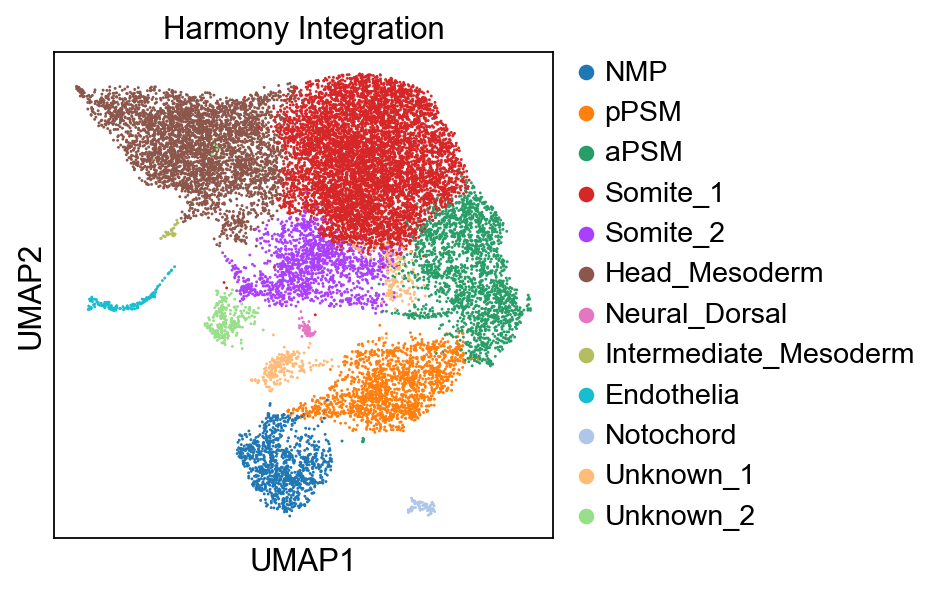

In [5]:
sc.pl.umap(adata, color='annotation', title="Harmony Integration")

In [6]:
# check that the matrix looks like normalized counts
print(adata.X[1:10,1:10])

  (0, 6)	0.547740638256073
  (3, 4)	0.33367305994033813
  (8, 4)	0.2874073386192322
  (8, 6)	0.510386049747467


### Loading data (Regression and scaling only)

In [7]:
adata2 = sc.read_h5ad("D:/BIOINFO/POURQUIE/HOX_project/Analysis_SCANPY/H5AD/20241113_HOXsamples_all_qc_filtered_dr_REGSCALLING_clustered_anno.h5ad")

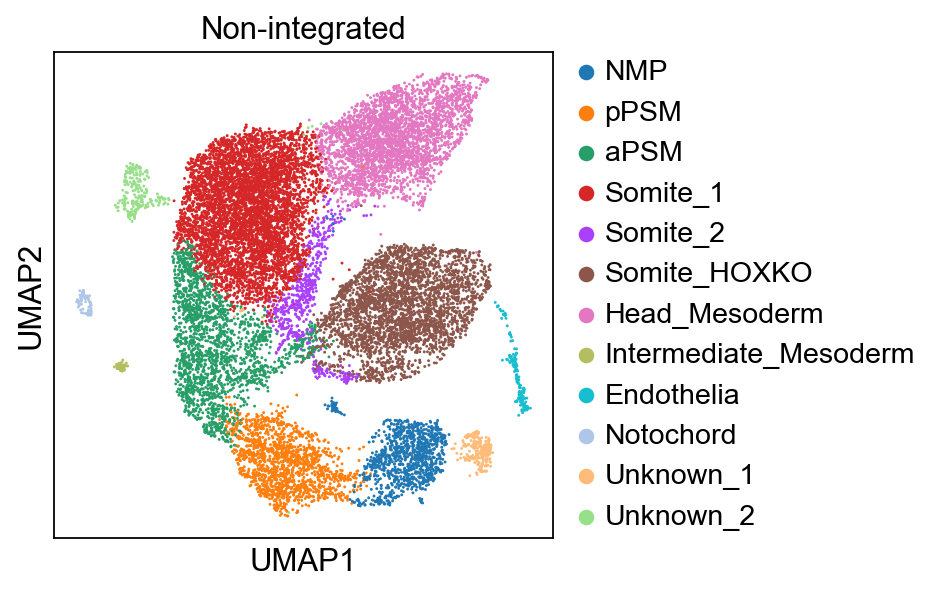

In [8]:
sc.pl.umap(adata2, color='annotation', title="Non-integrated")

In [9]:
# check that the matrix looks like normalized counts
print(adata2.X[1:10,1:10])

  (0, 6)	0.547740638256073
  (3, 4)	0.33367305994033813
  (8, 4)	0.2874073386192322
  (8, 6)	0.510386049747467


### Plotting marker genes per genotype

In [10]:
genes  = ["NKX1-2","SOX2","CDX2","CDX4", "TBXT",  # NMP
          "TBX6","MSGN1","HES7","MESP1","MESP2","MEOX1","RIPPLY1","FOXC2","MEOX2","ALDH1A2", 'PAX3','TCF15',"SIX1","EYA1","EYA2",  #Mesoderm
          "FOXA2", "NOTO","SHH",  #notochord
          "PAX6","MAP2", #dorsal neural
          "JAG1","PAX8","PAX2",  "GDNF", #nephric
          "TBX1","TWIST1","TCF21", # Head Mesoderm
          "KDR","SOX17", "CD34"  # endothelial
         ]

WT


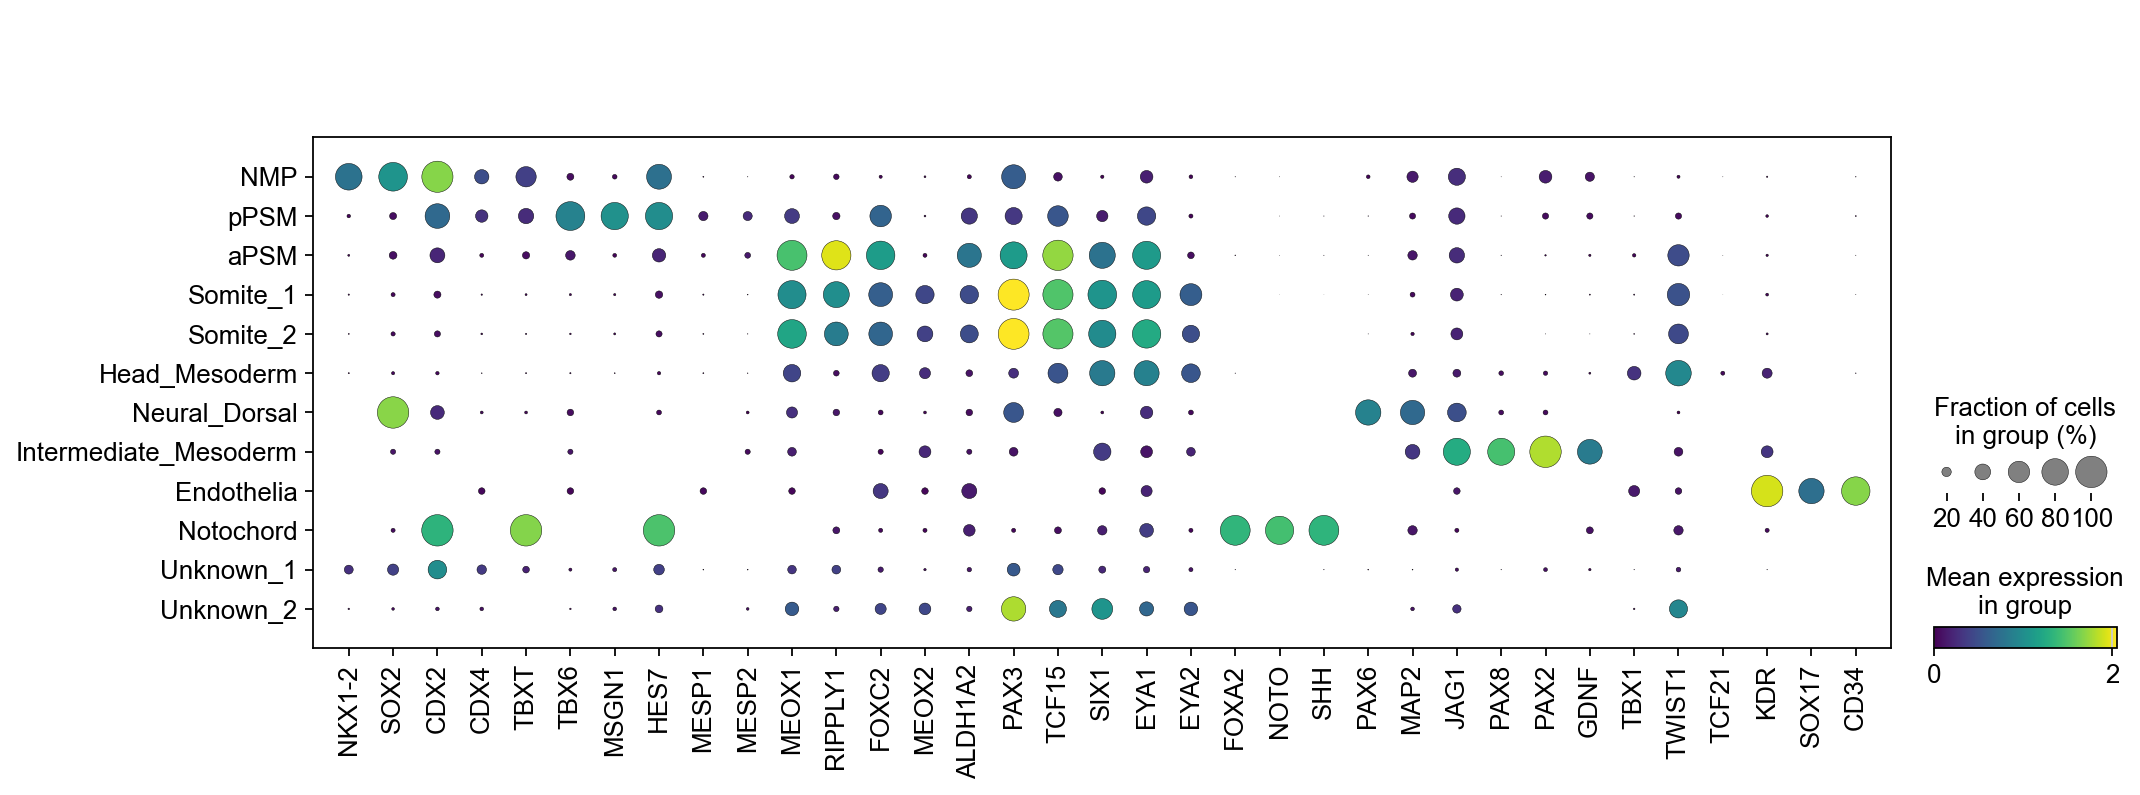

HOXD_KO


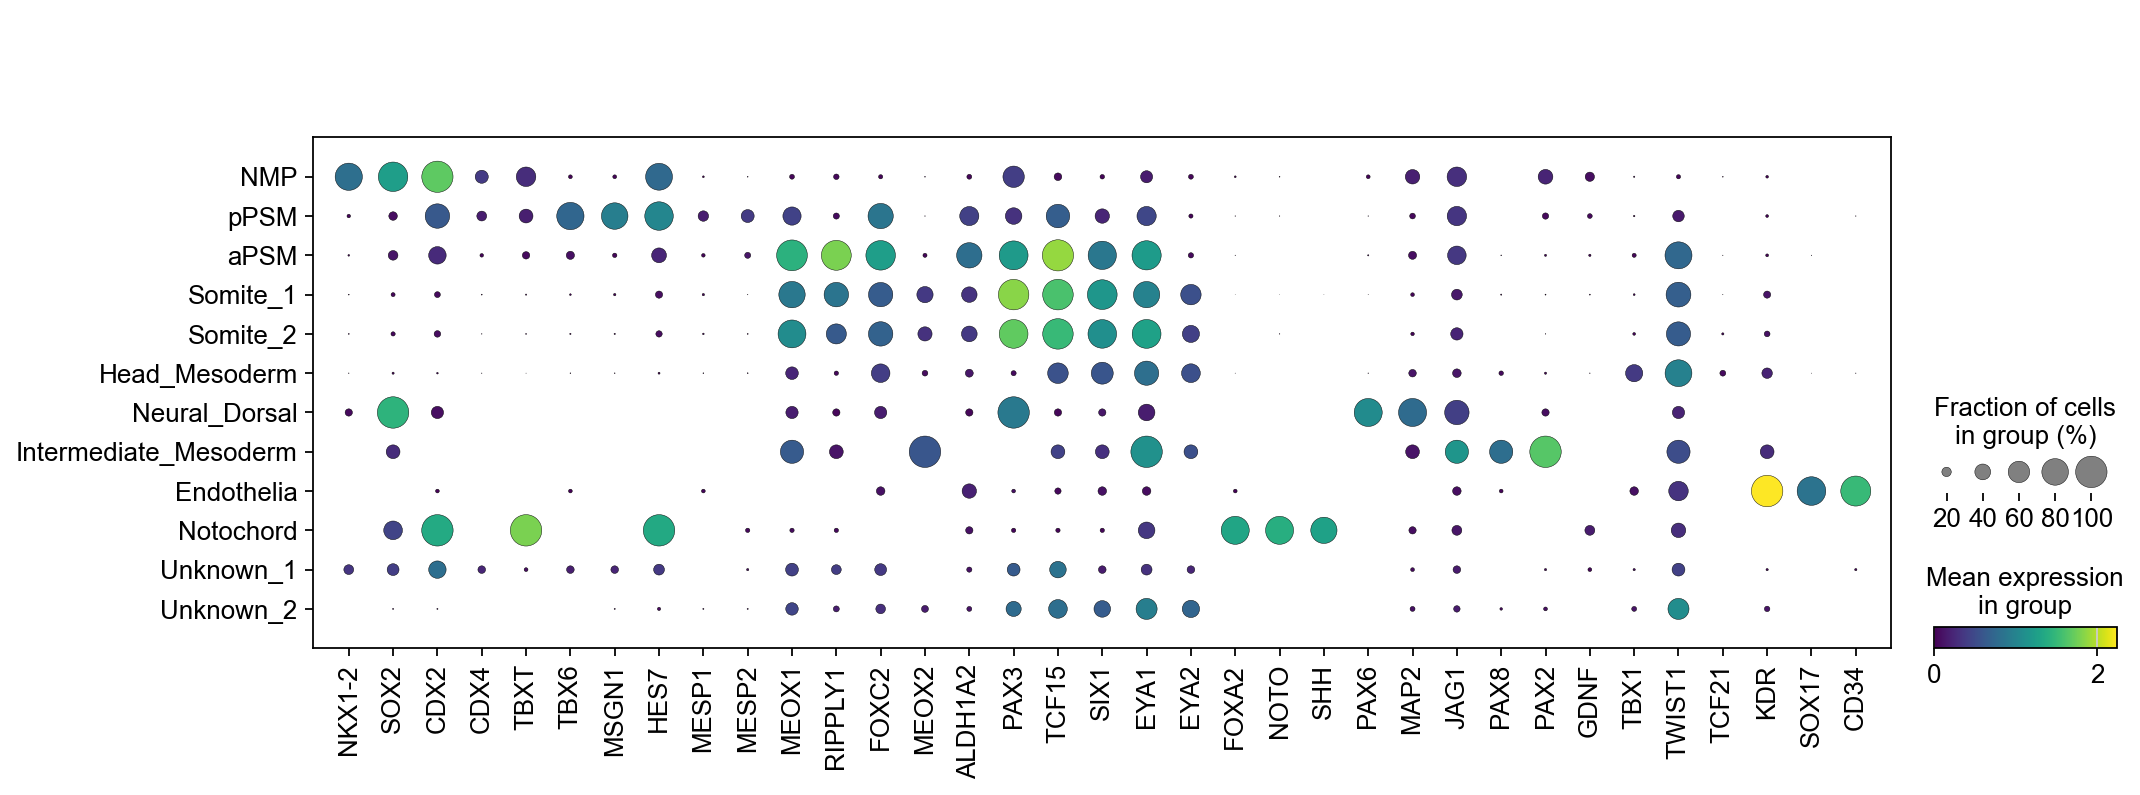

HOXBCD_KO


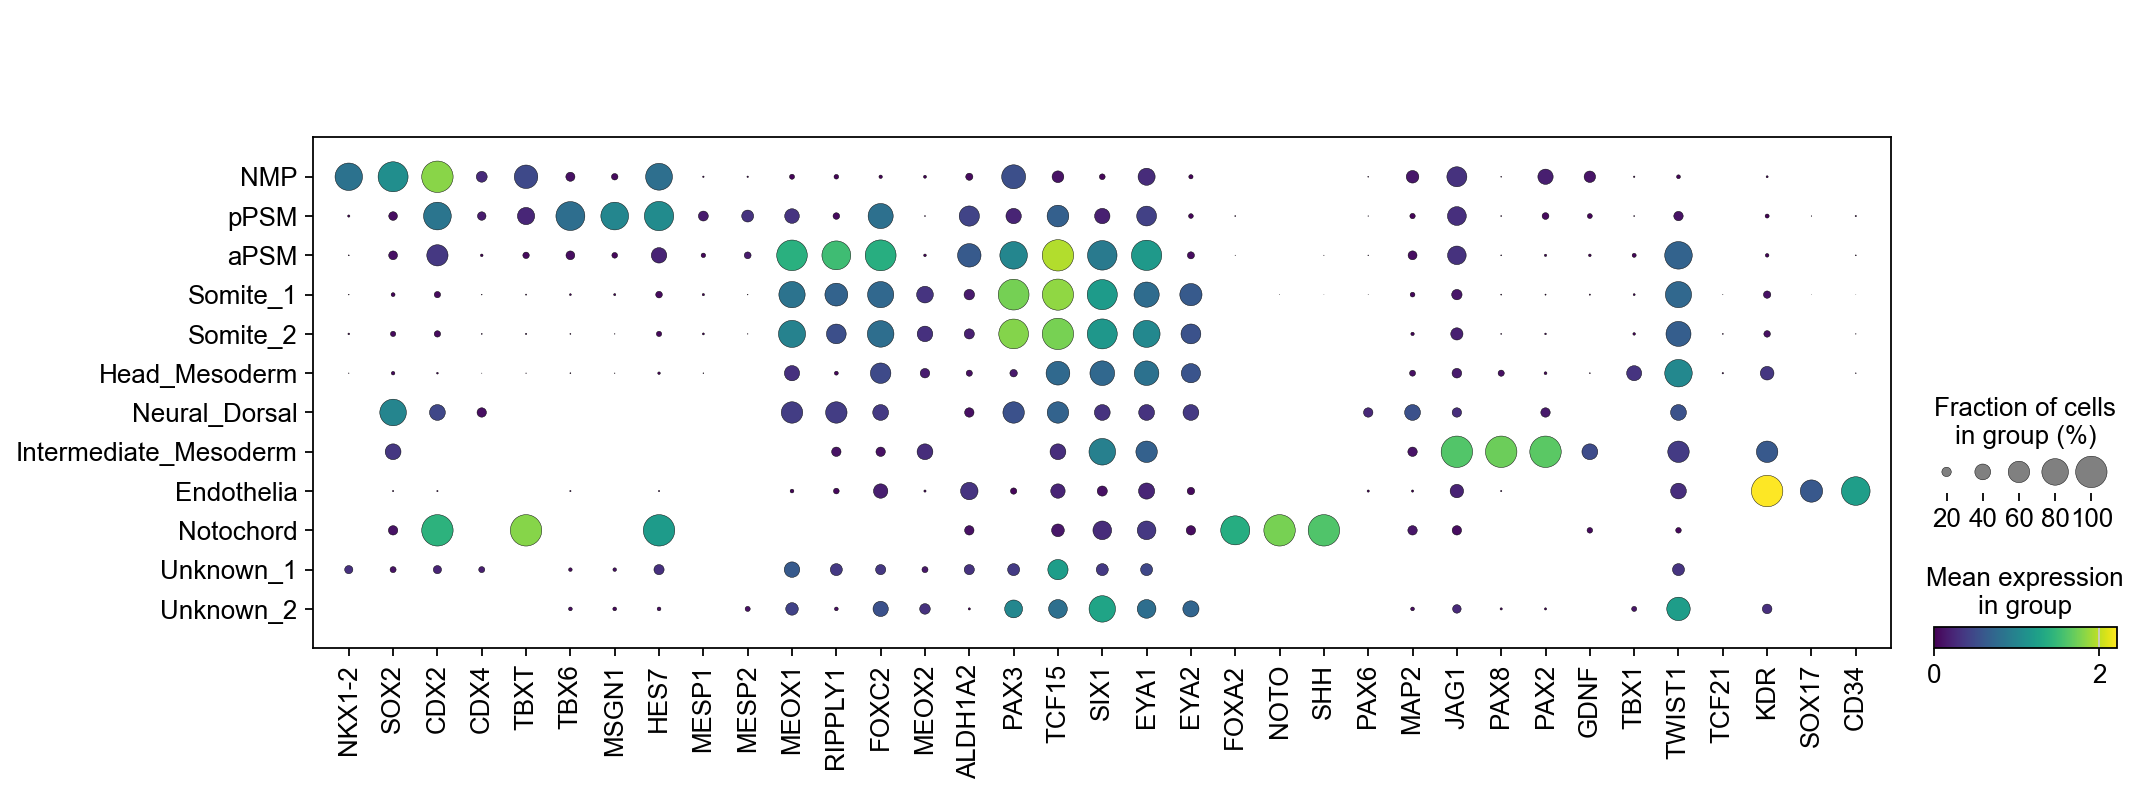

HOXCD_KO


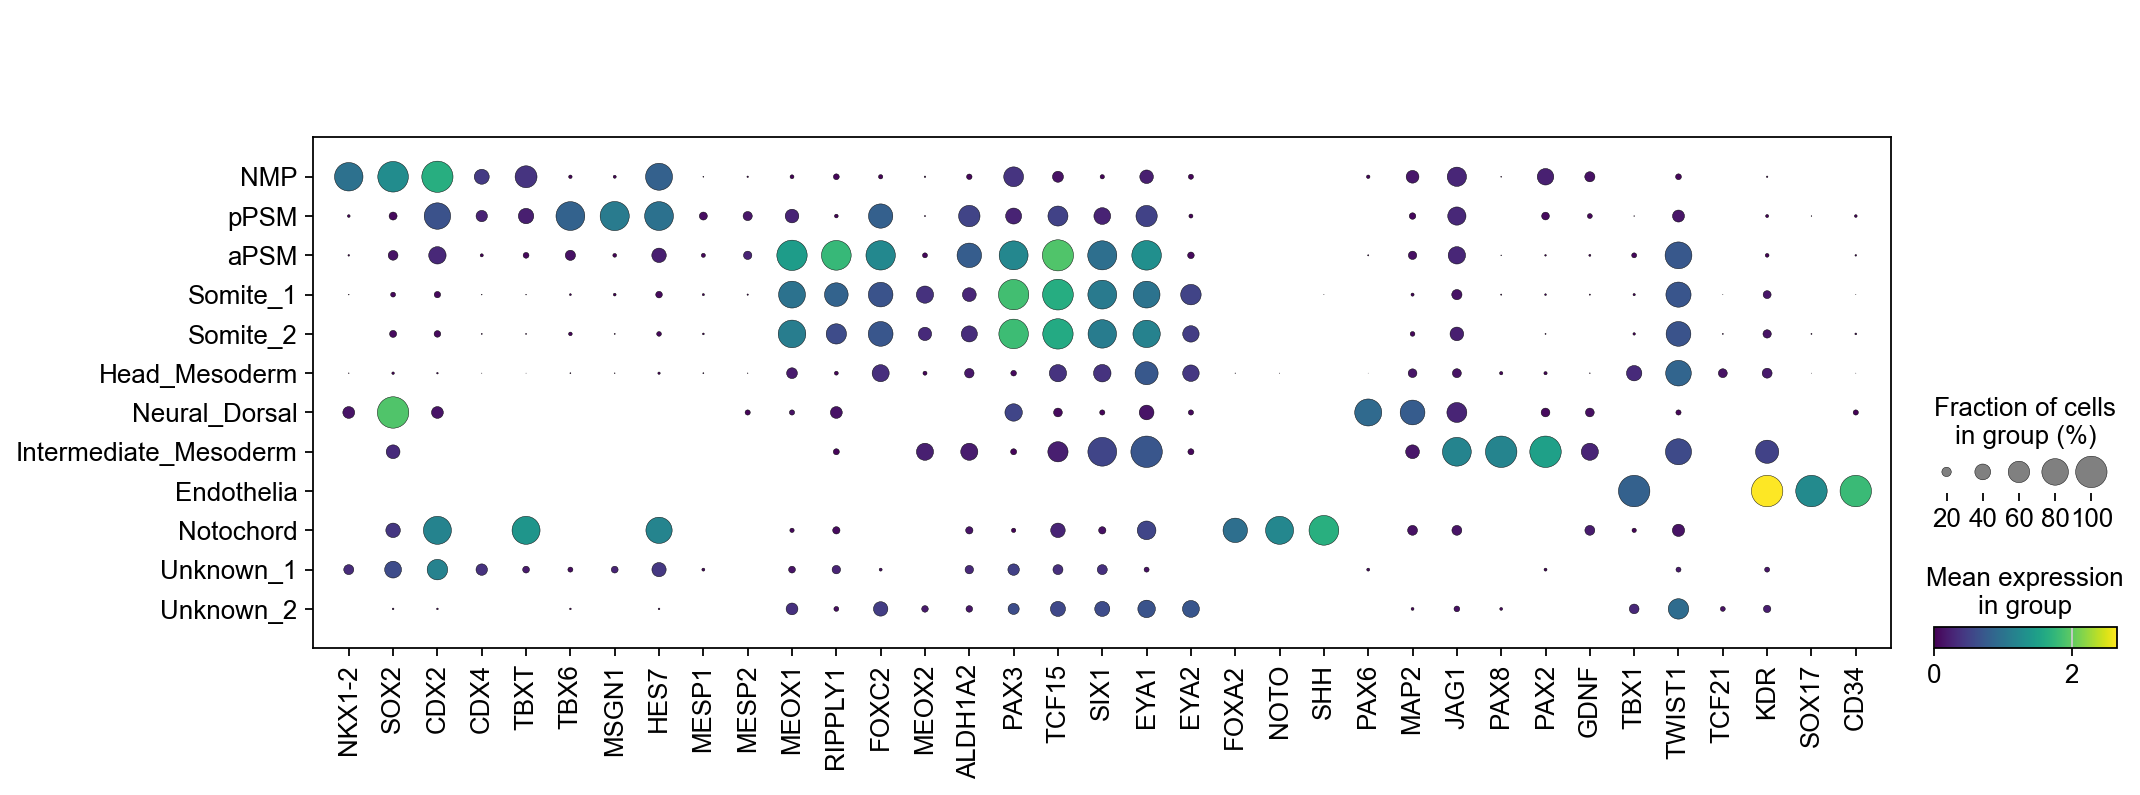

HOX_KO


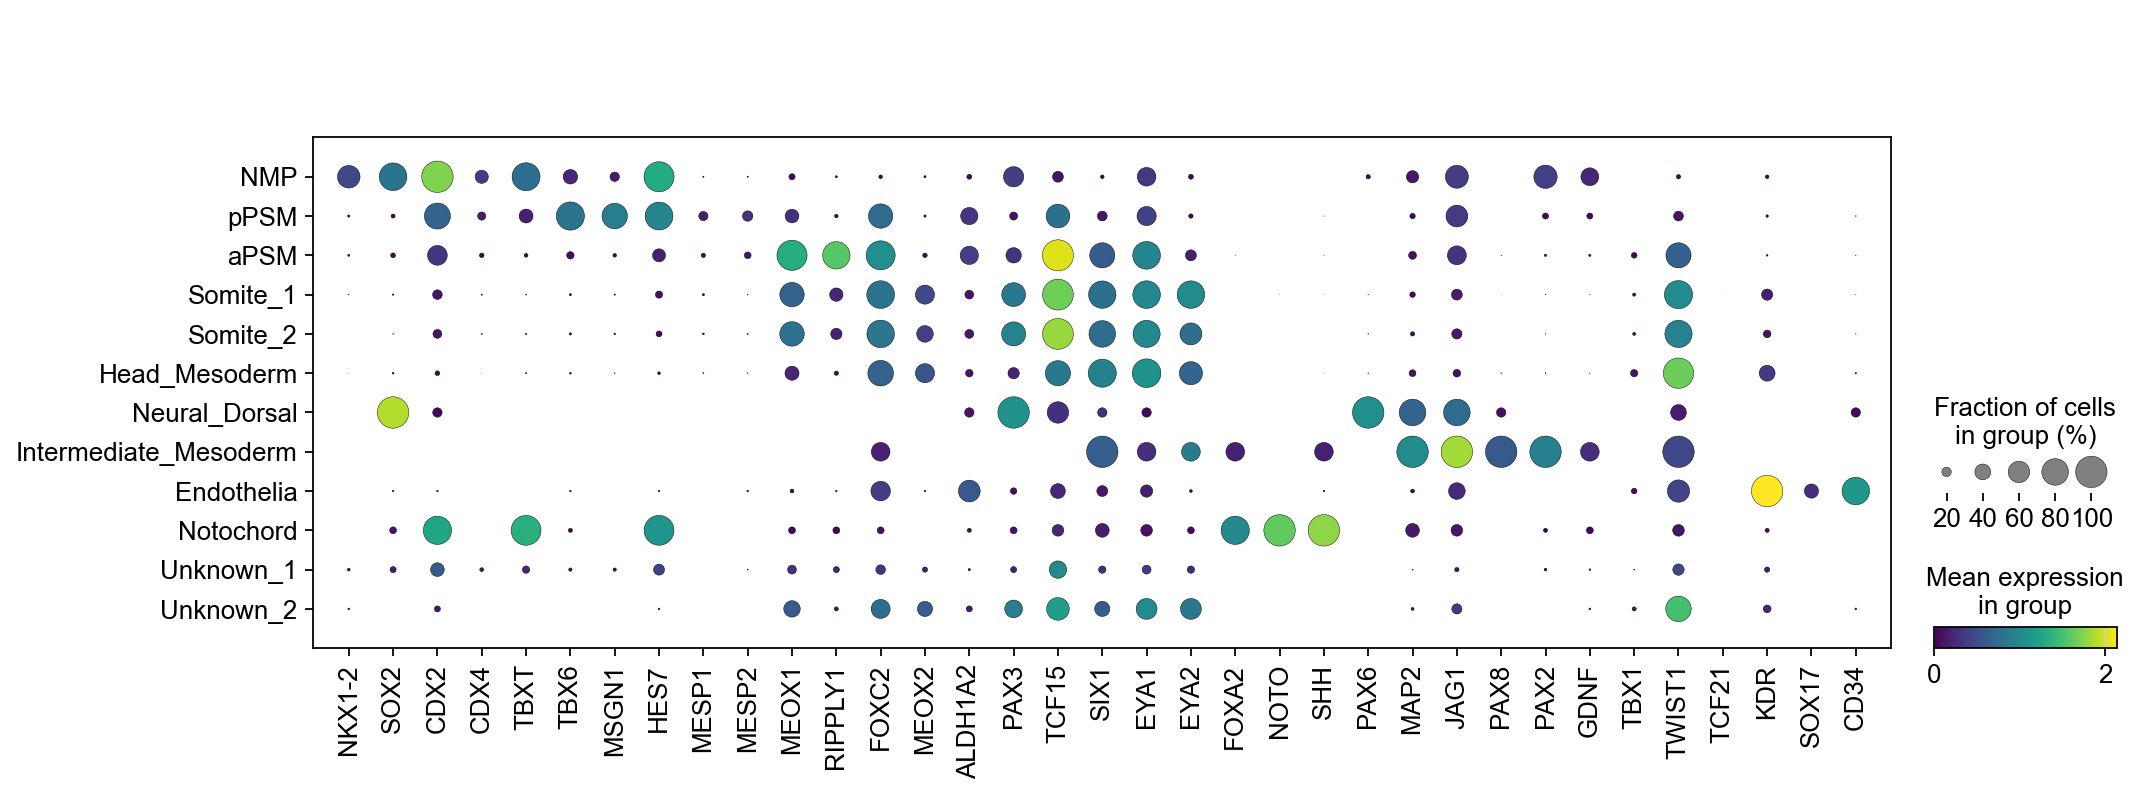

In [11]:
# Loop through each sample and plot a dot plot for the gene cluster
for i in ['WT', 'HOXD_KO', 'HOXBCD_KO', 'HOXCD_KO', 'HOX_KO']:
    print(i)
    sc.pl.dotplot(
        adata[adata.obs["sample"] == i],  # Subset the data for each sample
        var_names= genes,                 # Genes in the cluster
        groupby="annotation",             # Group by annotation
        color_map="viridis",             # Choose a color map
        save=f'20260217_HOXsamples_MARKERSdotplot_Harmony_{i}_allclusters.pdf'
    )

WT


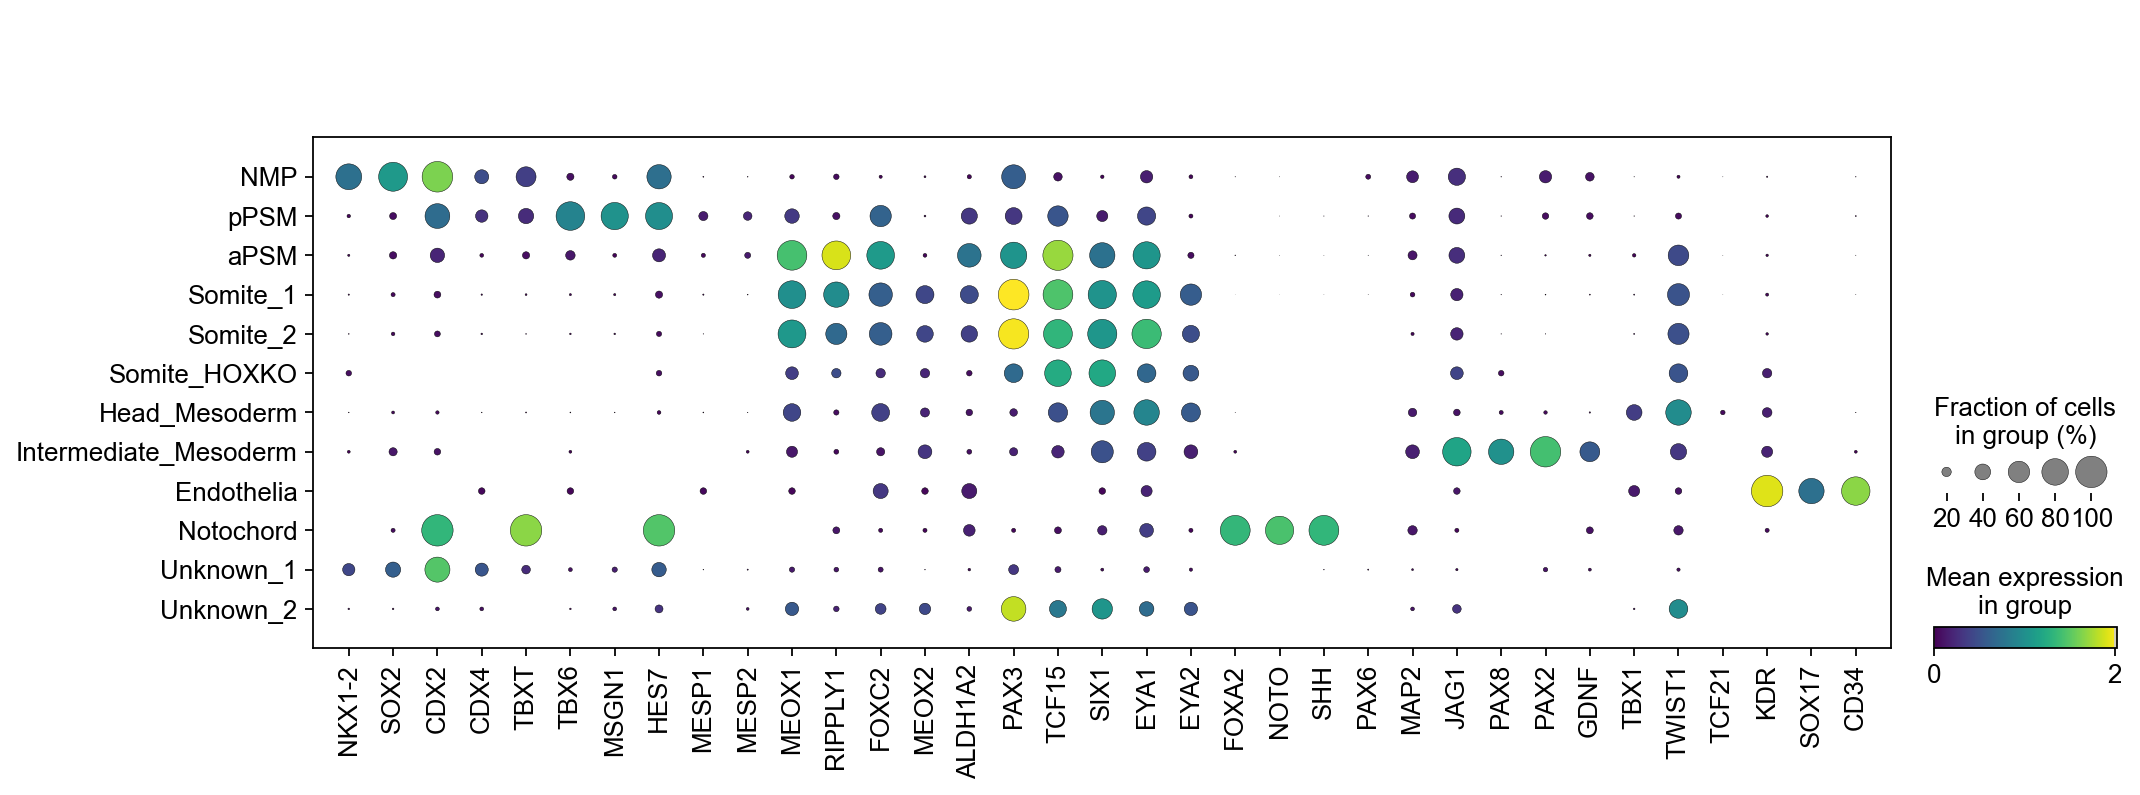

HOXD_KO


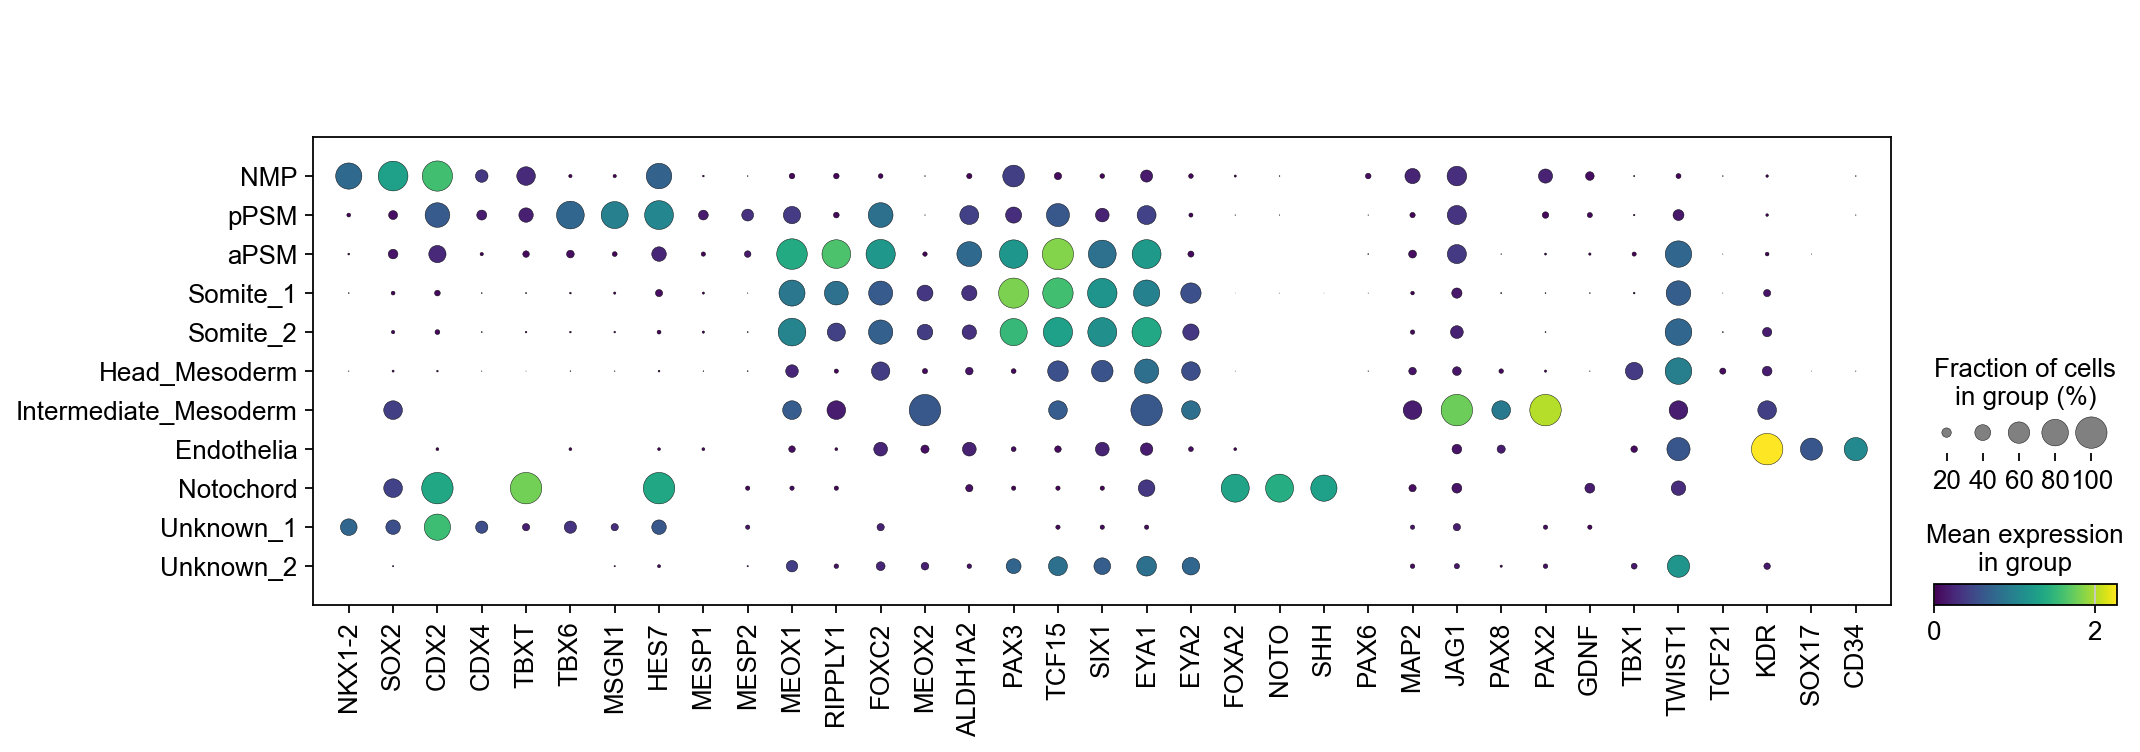

HOXBCD_KO


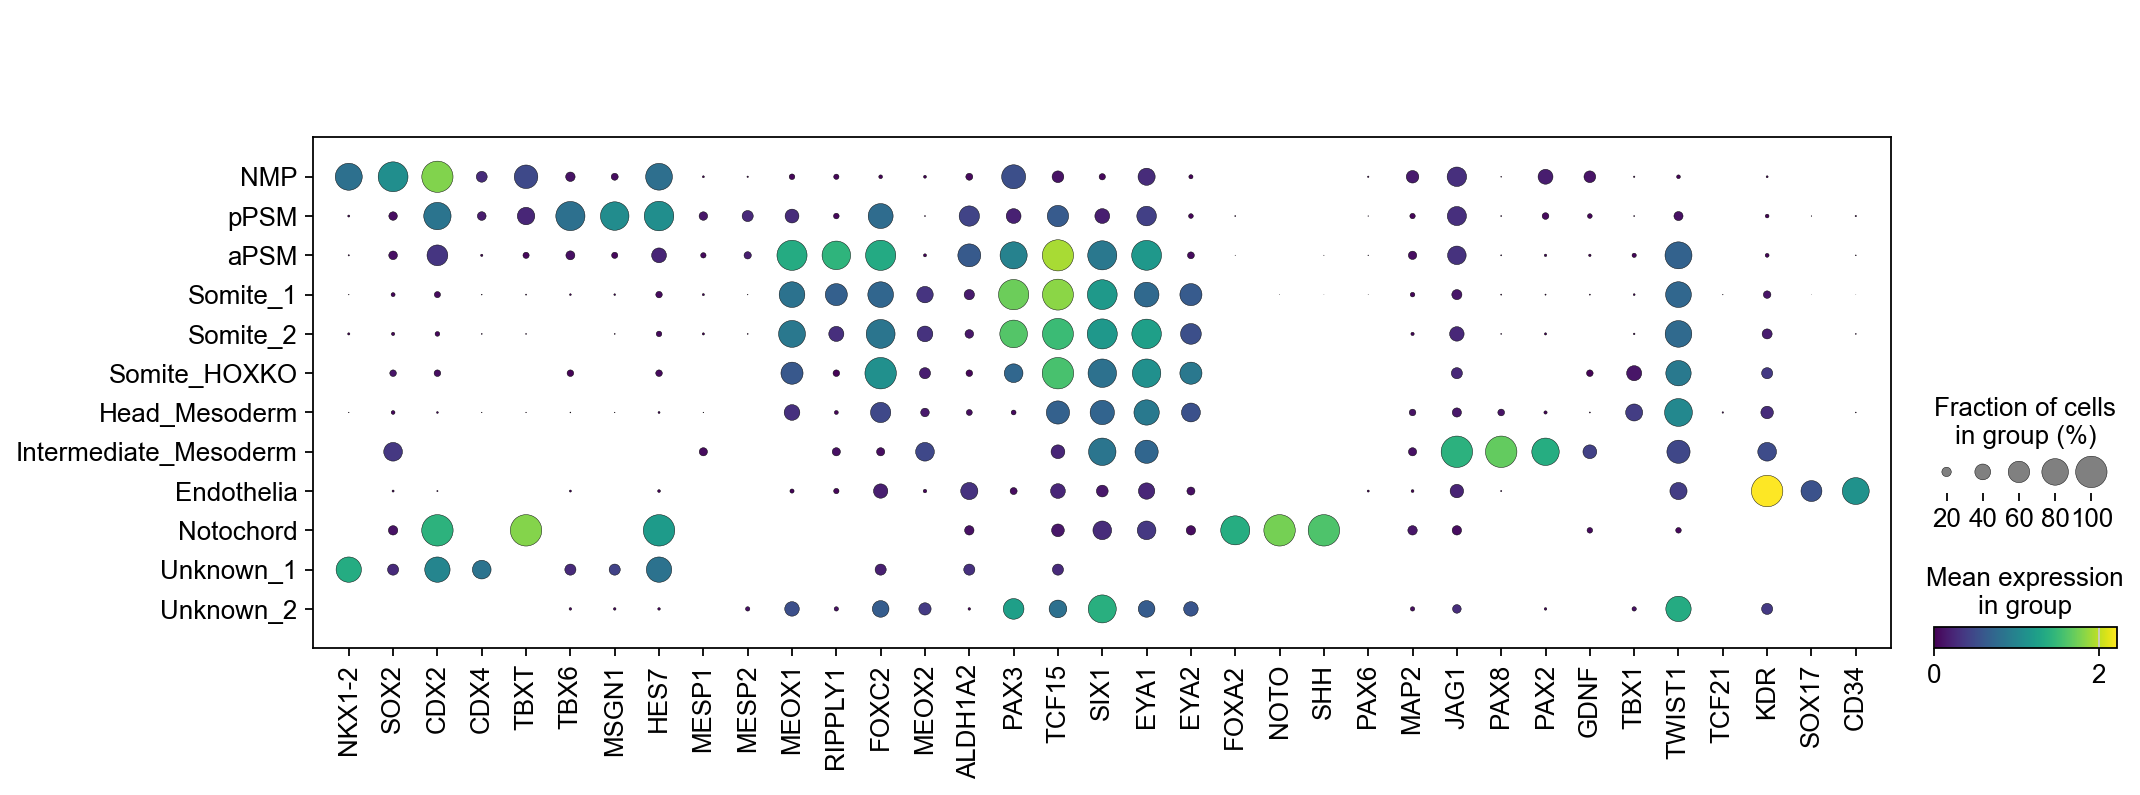

HOXCD_KO


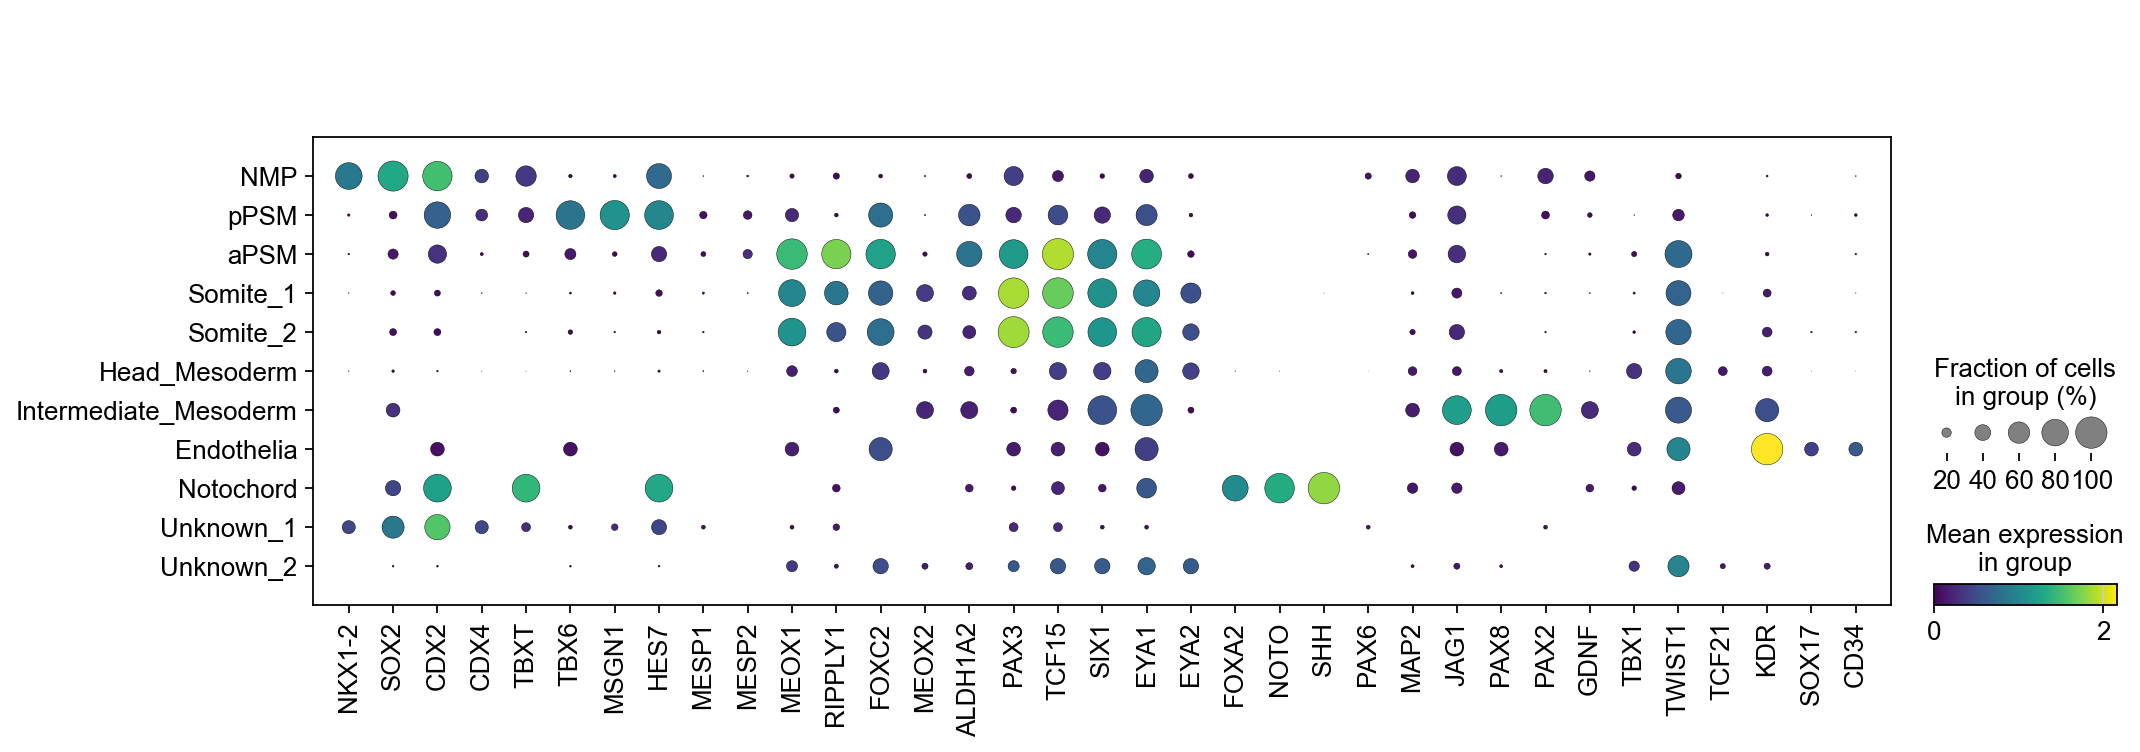

HOX_KO


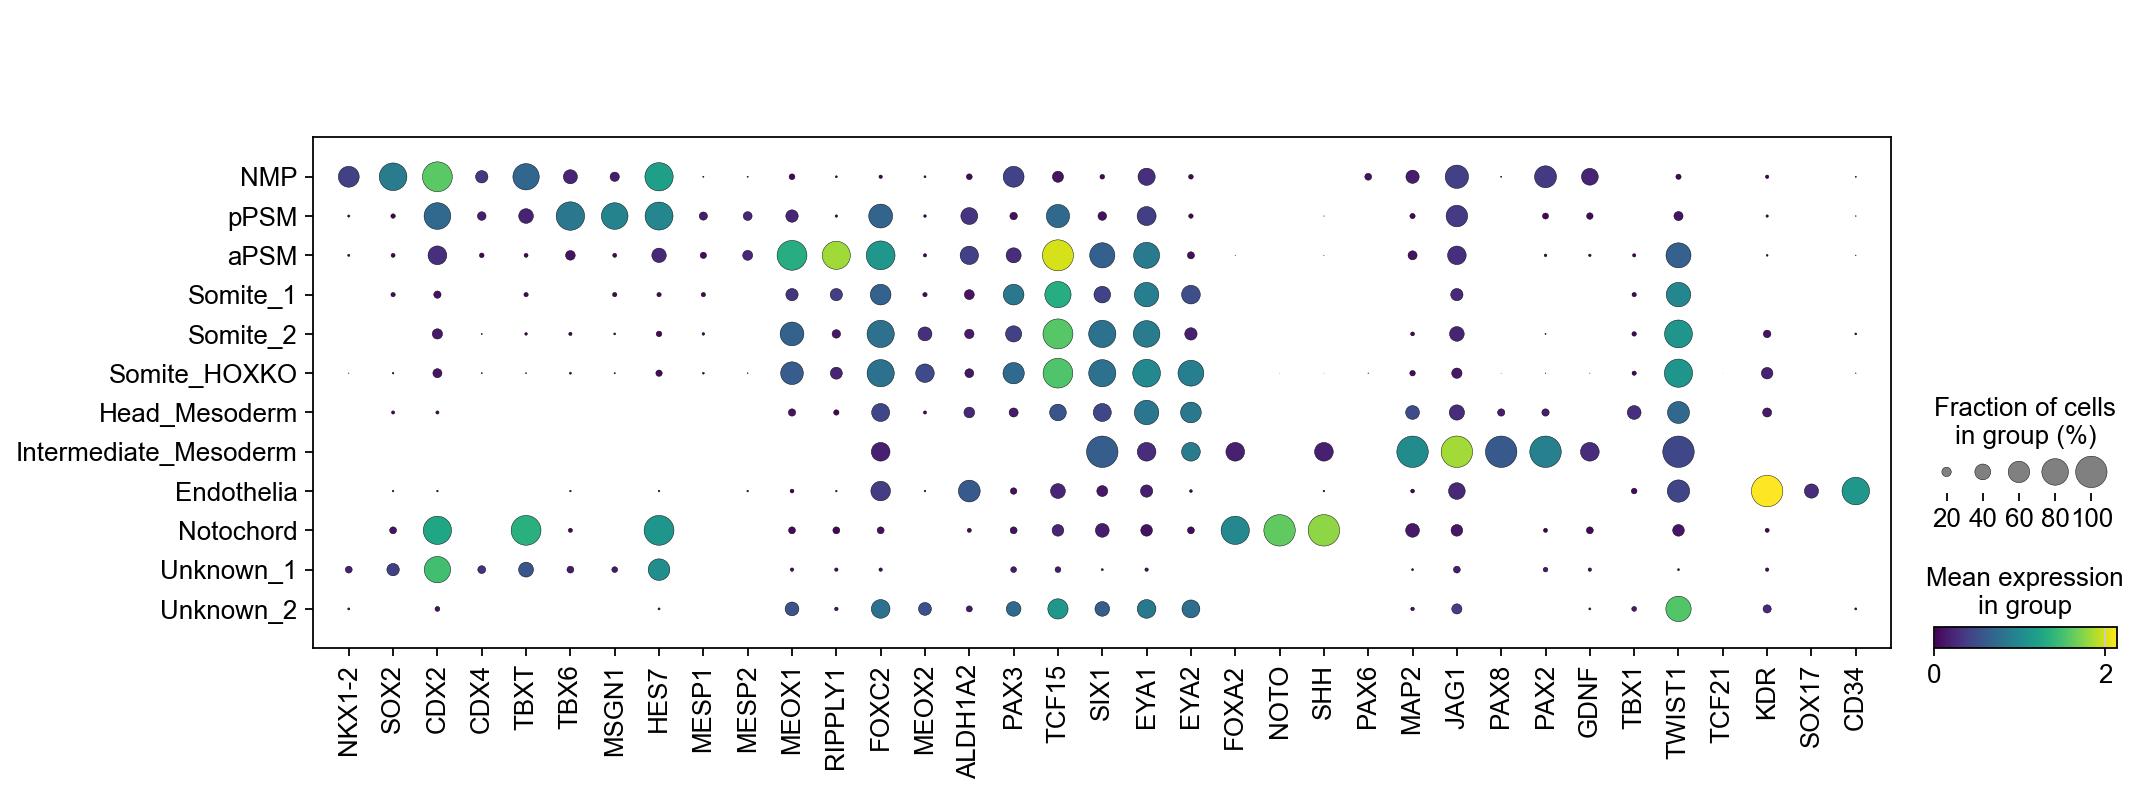

In [12]:
# Loop through each sample and plot a dot plot for the gene cluster
for i in ['WT', 'HOXD_KO', 'HOXBCD_KO', 'HOXCD_KO', 'HOX_KO']:
    print(i)
    sc.pl.dotplot(
        adata2[adata2.obs["sample"] == i],  # Subset the data for each sample
        var_names= genes,                 # Genes in the cluster
        groupby="annotation",             # Group by annotation
        color_map="viridis",             # Choose a color map
        save=f'20260217_HOXsamples_MARKERSdotplot_REGSCALLING_{i}_allclusters.pdf'
    )